In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# set the parameters 
num_samples = 5000
sample_size = 200
distribution_range = (0, 1) 

# generate samples from a unform distirbution 
samples = np.random.uniform(distribution_range[0], distribution_range[1], (num_samples, sample_size))

samples.shape

(5000, 200)

In [3]:
# Calculate the sample mean 
samples_mean = np.mean(samples, axis=1)

samples_mean

array([0.48187321, 0.54332741, 0.49749828, ..., 0.47874812, 0.5129999 ,
       0.48214477])

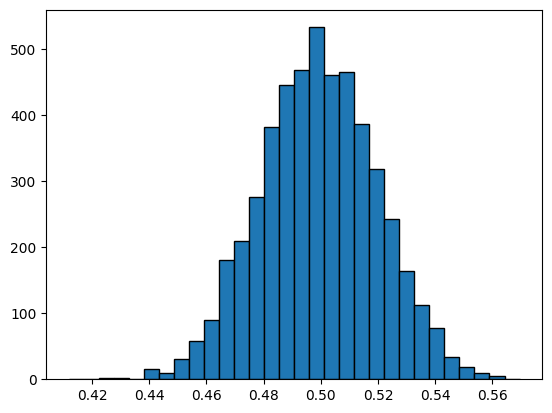

In [4]:
# plot the his plot 
plt.hist(samples_mean, bins=30, edgecolor='black');

<Axes: ylabel='Count'>

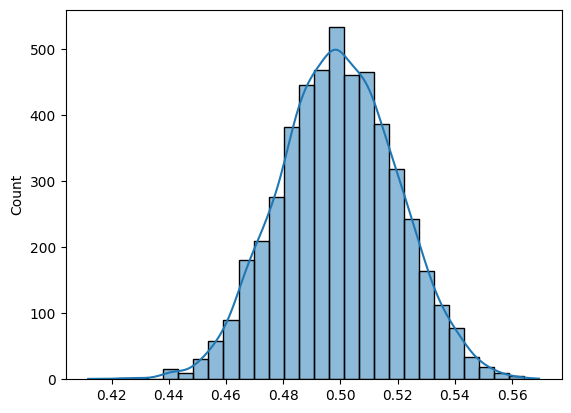

In [5]:
sns.histplot(samples_mean, bins=30, kde=True)

### Case Study 1. On Central Limit Theorom :- On the Fare Column of Titanic data  

In [6]:
# load datasets 
train_df = pd.read_csv('titanic/train.csv')
test_df = pd.read_csv('titanic/test.csv')

In [7]:
# concate the both df 
df = pd.concat([train_df.drop(columns='Survived'), test_df]).sample(1309) # population

In [8]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
365,366,3,"Adahl, Mr. Mauritz Nils Martin",male,30.0,0,0,C 7076,7.2500,NaN,S
560,561,3,"Morrow, Mr. Thomas Rowan",male,NaN,0,0,372622,7.7500,NaN,Q
475,476,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.0000,A14,S
571,572,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2,0,11769,51.4792,C101,S
80,81,3,"Waelens, Mr. Achille",male,22.0,0,0,345767,9.0000,NaN,S


Text(0.5, 1.0, 'Popualtion Fare Distribution')

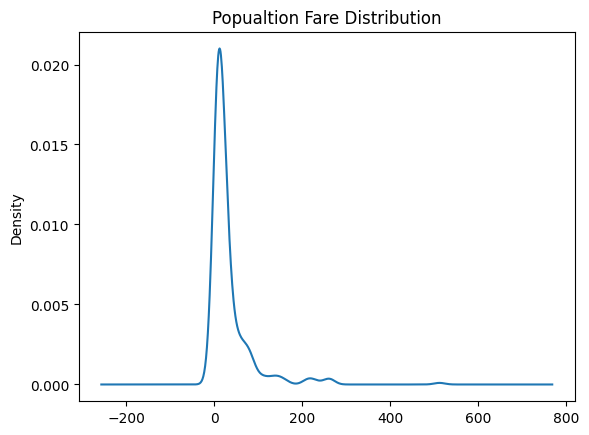

In [9]:
# see the distribution of fare 
df['Fare'].plot(kind='kde')
plt.title('Popualtion Fare Distribution')

In [10]:
# draw sample 
  # sample size = 50 
  # number of sample = 100

samples = []
for i in range(100):
    samples.append(df['Fare'].dropna().sample(50).values.tolist())

In [11]:
print(f'len : {len(samples)}')
print(f'Shape : {np.array(samples).shape}')

len : 100
Shape : (100, 50)


In [12]:
samples = np.array(samples)

In [13]:
# calculate the mean of every sample 
sampling_means = samples.mean(axis=1)

Text(0.5, 1.0, 'Sample Fare Distribution')

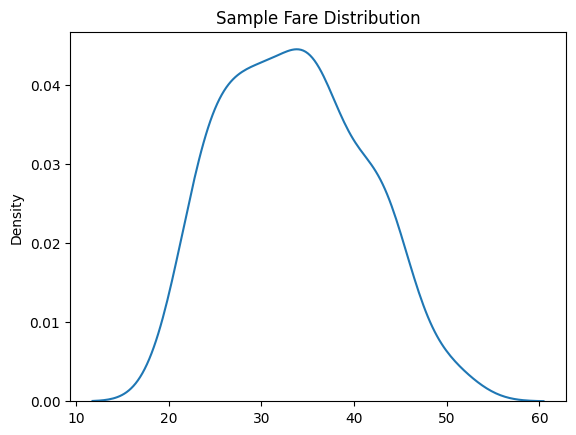

In [14]:
sns.kdeplot(sampling_means)
plt.title('Sample Fare Distribution')

In [15]:
sampling_means.mean()

np.float64(33.48943896)

In [16]:
# std 
sampling_means.std() / np.sqrt(50)

np.float64(1.0392560618240794)

In [17]:
lower_limit = sampling_means.mean() - 2*sampling_means.std() / np.sqrt(50)
upper_limit = sampling_means.mean() + 2*sampling_means.std() / np.sqrt(50)

In [18]:
print('There is 95% chances that the population mean is comes from this Range.')
print(f'Mean Range of sample data is : {lower_limit} - {upper_limit}')  
print(f'Mean of Population : {df['Fare'].mean()}')

There is 95% chances that the population mean is comes from this Range.
Mean Range of sample data is : 31.41092683635184 - 35.56795108364816
Mean of Population : 33.29547928134557


### Case Study 2. On Loan Data

In [2]:
loan_df = pd.read_csv('DataSets/loan_data.csv')
loan_df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


#### On Age column 

In [3]:
loan_df = loan_df.sample(45000)

Text(0.5, 1.0, 'Population Age Distribution')

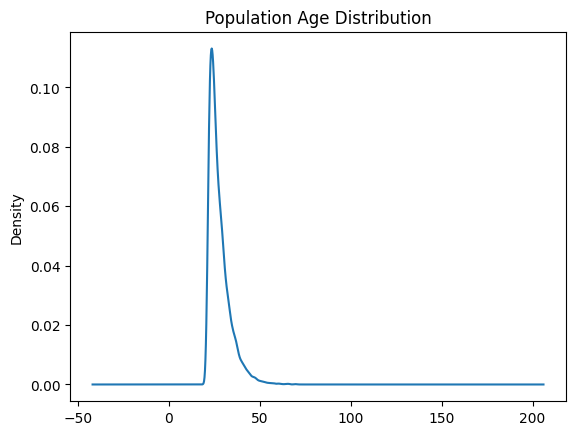

In [4]:
# see distribution of person_age 
loan_df['person_age'].plot(kind='kde')
plt.title('Population Age Distribution')

In [5]:
# draw sample 
  # sample size = 5000 
  # number of sample = 10000

samples = []
for i in range(10000):
    samples.append(loan_df['person_age'].sample(5000).values.tolist())

In [6]:
samples = np.array(samples)

In [7]:
samples.shape

(10000, 5000)

In [8]:
# calculate the mean of every sample 
sampling_means = samples.mean(axis=1)

In [9]:
sampling_means[:8]

array([27.7994, 27.734 , 27.8506, 27.7542, 27.82  , 27.6726, 27.7756,
       27.686 ])

Text(0.5, 1.0, 'Samples Age Distribution')

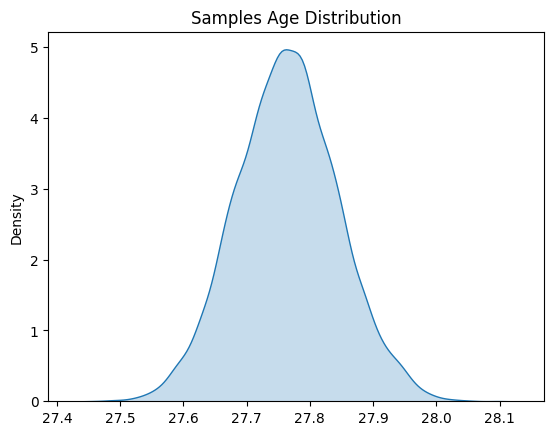

In [11]:
sns.kdeplot(sampling_means, fill=True)
plt.title('Samples Age Distribution')

In [12]:
lower_limit = sampling_means.mean() - 2*sampling_means.std() / np.sqrt(5000)
upper_limit = sampling_means.mean() + 2*sampling_means.std() / np.sqrt(5000)

In [13]:
print(f'Mean Range of sample data is : {lower_limit} - {upper_limit}')  
print(f'Mean of Population : {loan_df['person_age'].mean()}')

Mean Range of sample data is : 27.761195697080463 - 27.765757502919538
Mean of Population : 27.76417777777778


#### on person_income	

Text(0.5, 1.0, 'Population Person Income Distribution')

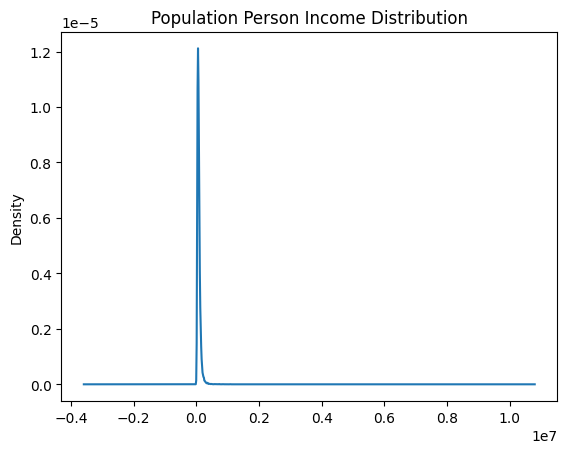

In [95]:
# see distribution of person_age 
loan_df['person_income'].plot(kind='kde')
plt.title('Population Person Income Distribution')

In [96]:
# draw sample 
  # sample size = 5000 
  # number of sample = 10000

samples = []
for i in range(10000):
    samples.append(loan_df['person_income'].sample(5000).values.tolist())

In [98]:
samples = np.array(samples)

In [99]:
# calculate the mean of every sample 
sampling_means = samples.mean(axis=1)

In [100]:
sampling_means[:8]

array([81789.2746, 79506.1598, 79156.6372, 78714.815 , 79687.6516,
       81777.403 , 80912.517 , 78573.4172])

Text(0.5, 1.0, 'Samples Person Income Distribution')

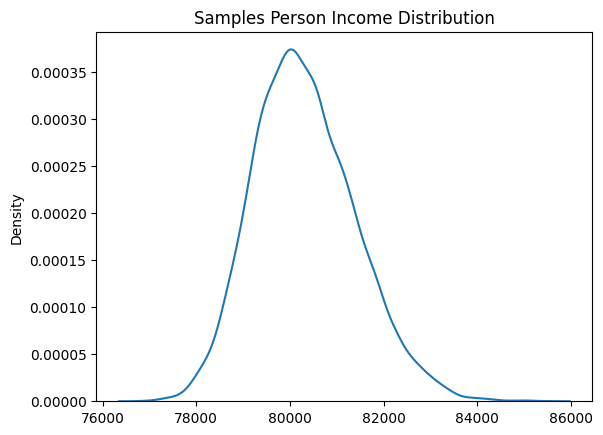

In [101]:
sns.kdeplot(sampling_means)
plt.title('Samples Person Income Distribution')

In [102]:
lower_limit = sampling_means.mean() - 2*sampling_means.std() / np.sqrt(5000)
upper_limit = sampling_means.mean() + 2*sampling_means.std() / np.sqrt(5000)

In [104]:
print(f'Mean Range of sample data is : {lower_limit} - {upper_limit}')  
print(f'Mean of Population : {loan_df['person_income'].mean()}')

Mean Range of sample data is : 80283.58897990303 - 80344.91607421698
Mean of Population : 80319.05322222222


#### on loan_amnt

Text(0.5, 1.0, 'Popualtion loan_amnt Distribution')

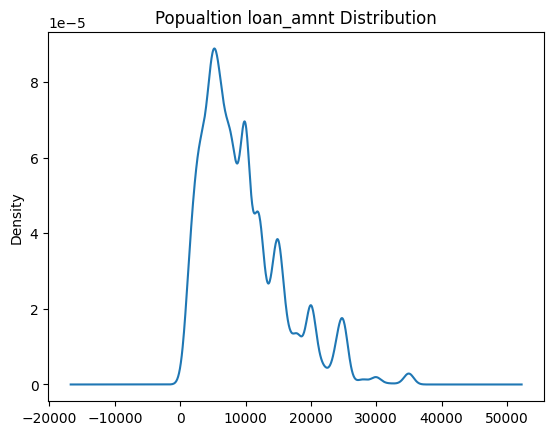

In [107]:
loan_df['loan_amnt'].plot(kind='kde')
plt.title('Popualtion loan_amnt Distribution')

In [116]:
# draw sample 
  # sample size = 5000 
  # number of sample = 20000

samples = []
for i in range(20000):
    samples.append(loan_df['loan_amnt'].sample(5000).values.tolist())

In [117]:
samples = np.array(samples)

In [118]:
# calculate the mean of every sample 
sampling_means = samples.mean(axis=1)

In [119]:
sampling_means[:8]

array([9607.2906, 9502.9352, 9576.6196, 9626.986 , 9594.9876, 9602.2766,
       9592.9112, 9643.125 ])

Text(0.5, 1.0, 'Samples loan_amnt Distribution')

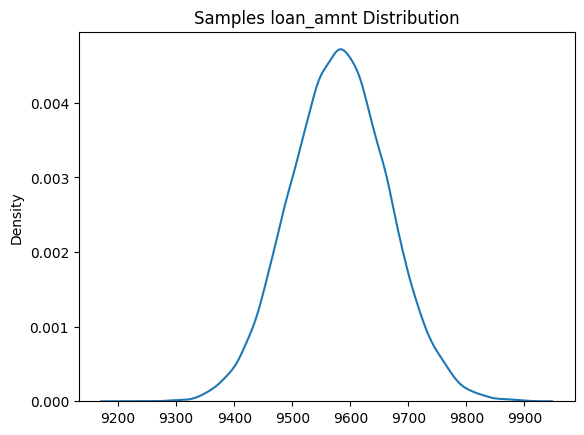

In [120]:
sns.kdeplot(sampling_means)
plt.title('Samples loan_amnt Distribution')

In [121]:
lower_limit = sampling_means.mean() - 2*sampling_means.std() / np.sqrt(5000)
upper_limit = sampling_means.mean() + 2*sampling_means.std() / np.sqrt(5000)

In [122]:
print(f'Mean Range of sample data is : {lower_limit} - {upper_limit}')  
print(f'Mean of Population : {loan_df['loan_amnt'].mean()}')

Mean Range of sample data is : 9579.033748899681 - 9583.79865048032
Mean of Population : 9583.157555555556
